## Setup & Imports


In [ ]:
import sqlite3, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FLOW_FEATURES = ['urine_volume', 'max_flow', 'avg_flow', 'micturition_time', 'flow_time', 'rise_time']
IPSS_FEATURES = ['ipss_score', 'ipss_delta_prev', 'ipss_days_since']
FEATURES = FLOW_FEATURES + IPSS_FEATURES

FEATURE_UNITS = {
    'urine_volume': 'ml',
    'max_flow': 'ml/s',
    'avg_flow': 'ml/s',
    'micturition_time': 's',
    'flow_time': 's',
    'rise_time': 's',
    'ipss_score': 'pts',
    'ipss_delta_prev': 'Δpts',
    'ipss_days_since': 'd',
}

# Reference / scaling values used by the UIs for visual feature bars
FEATURE_REFS = {
    'urine_volume': 400, 'max_flow': 30, 'avg_flow': 15,
    'micturition_time': 90, 'flow_time': 80, 'rise_time': 30,
    'ipss_score': 35, 'ipss_delta_prev': 15, 'ipss_days_since': 90,
}

IPSS_WINDOW_DAYS = 30  # max acceptable time gap between measurement and IPSS submission

UNCERTAINTY_THRESHOLD = 0.75

print('Setup completed')

## Connect database

Adjust DB_DIR and DB_NAME!

In [ ]:
DB_DIR = 'data/db/'
DB_NAME = 'data_mock.db'
DB_PATH = DB_DIR + DB_NAME

# ─── Demo: Creates mock data (measurements + patients + IPSS submissions)
# NOTE: delete the .db file to regenerate with the current schema.

import os
if not os.path.exists(DB_PATH):
    print('No valid database found - creating mock data')
    np.random.seed(42)

    def make_row(group_params):
        """Generate a single realistic uroflow measurement row."""
        p = group_params
        if np.random.random() < 0.12:
            urine_volume = np.random.uniform(50, 150) if np.random.random() < 0.5 else np.random.uniform(400, 700)
        else:
            urine_volume = np.clip(np.random.normal(p['vol_mean'], p['vol_std']), 100, 600)

        max_flow = max(3.0, np.random.normal(p['max_mean'], p['max_std']))
        ratio = np.random.uniform(p['ratio_lo'], p['ratio_hi'])
        avg_flow = min(max(1.0, max_flow * ratio), max_flow - 0.5)

        flow_time = max(5.0, np.random.normal(p['ft_mean'], p['ft_std']))
        micturition_time = max(flow_time, flow_time + np.random.uniform(0, p['pause_extra']))
        rise_time = min(max(1.0, np.random.normal(p['rt_mean'], p['rt_std'])), flow_time * 0.5)

        return dict(
            urine_volume=round(urine_volume, 1),
            max_flow=round(max_flow, 1),
            avg_flow=round(avg_flow, 1),
            micturition_time=round(micturition_time, 1),
            flow_time=round(flow_time, 1),
            rise_time=round(rise_time, 1),
        )

    # Wider standard deviations create overlap between severity classes so
    # flow features alone cannot perfectly separate all cases — IPSS can then
    # contribute as a tie-breaker on genuinely ambiguous measurements.
    groups = [
        dict(vol_mean=240, vol_std=70, max_mean=24, max_std=8,
             ratio_lo=0.50, ratio_hi=0.78, ft_mean=22, ft_std=8,
             rt_mean=5, rt_std=3, pause_extra=6,
             ipss_mean=4, ipss_std=4),                   # normal
        dict(vol_mean=210, vol_std=75, max_mean=13, max_std=5.5,
             ratio_lo=0.47, ratio_hi=0.75, ft_mean=38, ft_std=13,
             rt_mean=12, rt_std=6, pause_extra=14,
             ipss_mean=13, ipss_std=5),                  # warning
        dict(vol_mean=190, vol_std=65, max_mean=7, max_std=3.5,
             ratio_lo=0.42, ratio_hi=0.70, ft_mean=55, ft_std=17,
             rt_mean=20, rt_std=8, pause_extra=22,
             ipss_mean=25, ipss_std=6),                  # critical
    ]

    # Assign 100 patients into severity groups with 60/25/15 ratio
    n_patients = 100
    patient_group = {}
    for i in range(n_patients):
        r = np.random.random()
        gi = 0 if r < 0.60 else (1 if r < 0.85 else 2)
        patient_group[f'P{i+1:03d}'] = gi

    start = datetime(2024, 1, 1)
    end   = start + timedelta(days=700)

    # Each patient gets 1–5 measurements, capped overall at 300
    rows = []
    for pid, gi in patient_group.items():
        for _ in range(np.random.randint(1, 6)):
            r = make_row(groups[gi])
            r['patient_id'] = pid
            r['created_date'] = (start + timedelta(days=int(np.random.randint(0, 700)))).isoformat()
            rows.append(r)
    np.random.shuffle(rows)
    rows = rows[:300]

    # IPSS submissions: two sources combined
    # 1. Historical baseline per patient — gives the delta feature a prior score to compute against
    # 2. Visit-coupled submissions — ~85% of measurements have an IPSS within ±20 days,
    #    reflecting real clinic workflow (IPSS and uroflow collected in the same visit)
    ipss_rows = []

    for pid, gi in patient_group.items():
        for off in sorted(np.random.randint(0, 700, size=np.random.randint(0, 3))):
            score = int(np.clip(np.random.normal(groups[gi]['ipss_mean'], groups[gi]['ipss_std']), 0, 35))
            ipss_rows.append({
                'patient_id': pid,
                'submitted_at': (start + timedelta(days=int(off))).isoformat(),
                'score': score,
            })

    COUPLING_PROB = 0.85
    for m in rows:
        if np.random.random() >= COUPLING_PROB:
            continue
        gi = patient_group[m['patient_id']]
        m_date = datetime.fromisoformat(m['created_date'])
        sub_date = m_date + timedelta(days=int(np.random.randint(-20, 21)))
        if not (start <= sub_date <= end):
            continue
        score = int(np.clip(np.random.normal(groups[gi]['ipss_mean'], groups[gi]['ipss_std']), 0, 35))
        ipss_rows.append({
            'patient_id': m['patient_id'],
            'submitted_at': sub_date.isoformat(),
            'score': score,
        })

    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    conn.execute('''
        CREATE TABLE IF NOT EXISTS measurements (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id       TEXT,
            created_date     TEXT,
            urine_volume     REAL,
            max_flow         REAL,
            avg_flow         REAL,
            micturition_time REAL,
            flow_time        REAL,
            rise_time        REAL,
            ipss_score       REAL,
            ipss_delta_prev  REAL,
            ipss_days_since  REAL,
            label            TEXT DEFAULT NULL,
            label_source     TEXT DEFAULT NULL,
            confidence       REAL DEFAULT NULL,
            reviewed_at      TEXT DEFAULT NULL
        )''')
    conn.execute('''
        CREATE TABLE IF NOT EXISTS ipss_submissions (
            submission_id INTEGER PRIMARY KEY AUTOINCREMENT,
            patient_id    TEXT,
            submitted_at  TEXT,
            score         INTEGER
        )''')
    for r in rows:
        conn.execute(
            '''INSERT INTO measurements
               (patient_id, created_date, urine_volume, max_flow, avg_flow,
                micturition_time, flow_time, rise_time)
               VALUES (?,?,?,?,?,?,?,?)''',
            (r['patient_id'], r['created_date'], r['urine_volume'], r['max_flow'],
             r['avg_flow'], r['micturition_time'], r['flow_time'], r['rise_time']))
    for r in ipss_rows:
        conn.execute(
            'INSERT INTO ipss_submissions (patient_id, submitted_at, score) VALUES (?,?,?)',
            (r['patient_id'], r['submitted_at'], r['score']))
    conn.commit()
    print(f'Mock data created: {len(rows)} measurements, {len(ipss_rows)} IPSS submissions, {n_patients} patients')
else:
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    existing = {r[1] for r in conn.execute("PRAGMA table_info(measurements)")}
    new_cols = [
        ('patient_id', 'TEXT'), ('created_date', 'TEXT'),
        ('ipss_score', 'REAL'), ('ipss_delta_prev', 'REAL'), ('ipss_days_since', 'REAL'),
        ('label', 'TEXT'), ('label_source', 'TEXT'),
        ('confidence', 'REAL'), ('reviewed_at', 'TEXT'),
    ]
    for col, typ in new_cols:
        if col not in existing:
            conn.execute(f'ALTER TABLE measurements ADD COLUMN {col} {typ}')
    conn.commit()
    print(f'Database connected: {DB_PATH}')

total   = conn.execute('SELECT COUNT(*) FROM measurements').fetchone()[0]
labeled = conn.execute("SELECT COUNT(*) FROM measurements WHERE label IS NOT NULL").fetchone()[0]
print(f'   {total} total measurements  |  {labeled} labeled  |  {total-labeled} unlabeled')

## IPSS feature enrichment

For each measurement, join the closest IPSS submission (within `IPSS_WINDOW_DAYS`) of the same patient and compute three features:

- `ipss_score` — score of the closest submission (NaN if no match within the window)
- `ipss_delta_prev` — difference to the patient's preceding submission (NaN if none exists)
- `ipss_days_since` — signed distance in days (negative = submission before measurement)

NaNs are kept — XGBoost handles missing values natively.

In [ ]:
def enrich_ipss_features(conn, window_days=IPSS_WINDOW_DAYS):
    """Populate ipss_score / ipss_delta_prev / ipss_days_since per measurement."""
    subs = pd.read_sql('SELECT patient_id, submitted_at, score FROM ipss_submissions', conn)
    if subs.empty:
        print('No IPSS submissions in DB — skipping enrichment.')
        return 0, 0
    subs['submitted_at'] = pd.to_datetime(subs['submitted_at'])
    subs = subs.sort_values(['patient_id', 'submitted_at']).reset_index(drop=True)

    meas = pd.read_sql('SELECT id, patient_id, created_date FROM measurements', conn)
    meas['created_date'] = pd.to_datetime(meas['created_date'])

    n_matched = 0
    for _, m in meas.iterrows():
        pid, m_date = m['patient_id'], m['created_date']
        if pid is None or pd.isna(m_date):
            continue
        ps = subs[subs['patient_id'] == pid]
        if ps.empty:
            continue

        days_diff = (ps['submitted_at'] - m_date).dt.total_seconds() / 86400.0
        abs_days = days_diff.abs()
        within = abs_days <= window_days
        if not within.any():
            continue

        idx_closest = abs_days[within].idxmin()
        closest = ps.loc[idx_closest]
        days_since = float(days_diff.loc[idx_closest])
        score = float(closest['score'])

        # Previous submission of the same patient, strictly before the matched one
        prior = ps[ps['submitted_at'] < closest['submitted_at']]
        delta = float(score - prior.iloc[-1]['score']) if len(prior) else None

        conn.execute('''UPDATE measurements
                        SET ipss_score=?, ipss_delta_prev=?, ipss_days_since=?
                        WHERE id=?''',
                     (score, delta, days_since, int(m['id'])))
        n_matched += 1

    conn.commit()
    return n_matched, len(meas)

n_matched, n_total = enrich_ipss_features(conn)
coverage = (n_matched / n_total * 100) if n_total else 0
print(f'IPSS enrichment: {n_matched}/{n_total} measurements matched within ±{IPSS_WINDOW_DAYS} days ({coverage:.1f}%)')

df_check = pd.read_sql('SELECT ipss_score, ipss_delta_prev, ipss_days_since FROM measurements', conn)
print('\nIPSS feature summary:')
print(df_check.describe().round(2))

## Data exploration


In [ ]:
df_all = pd.read_sql('SELECT * FROM measurements', conn)
print(f'Shape: {df_all.shape}')
df_all[FEATURES].describe().round(2)

In [ ]:
# Flow feature histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = sns.color_palette('muted', 6)
for ax, feat, col in zip(axes.flat, FLOW_FEATURES, colors):
    data = df_all[feat].dropna()
    ax.hist(data, bins=30, color=col, alpha=0.8, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel(FEATURE_UNITS[feat])
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='#333', ls='--', lw=1.2, label=f'Median {data.median():.1f}')
    ax.legend(fontsize=8)
fig.suptitle('Distribution of uroflow features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# IPSS feature histograms (separate because semantics differ)
ipss_data = df_all[IPSS_FEATURES].dropna(how='all')
if len(ipss_data):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    ipss_colors = sns.color_palette('muted', 3)
    for ax, feat, col in zip(axes, IPSS_FEATURES, ipss_colors):
        data = df_all[feat].dropna()
        if len(data) == 0:
            ax.set_title(f'{feat} (no data)'); ax.axis('off'); continue
        ax.hist(data, bins=20, color=col, alpha=0.8, edgecolor='white')
        ax.set_title(feat.replace('_', ' '))
        ax.set_xlabel(FEATURE_UNITS[feat])
        ax.set_ylabel('Frequency')
        ax.axvline(data.median(), color='#333', ls='--', lw=1.2, label=f'Median {data.median():.1f}')
        ax.legend(fontsize=8)
    fig.suptitle('Distribution of IPSS features', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

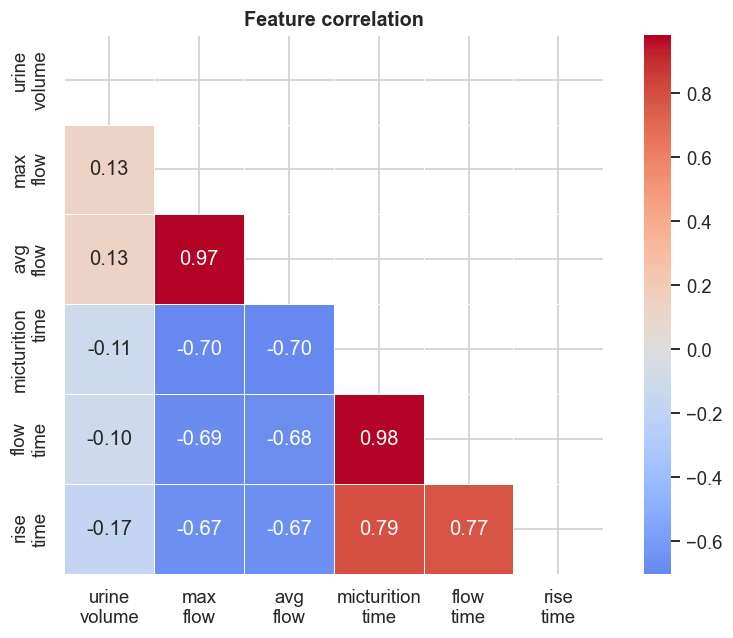

In [5]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_all[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=.5,
            xticklabels=[f.replace('_','\n') for f in FEATURES],
            yticklabels=[f.replace('_','\n') for f in FEATURES])
ax.set_title('Feature correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Active Learning Engine


In [ ]:
def _notnan(v):
    return v is not None and not (isinstance(v, float) and np.isnan(v))


# Clinical safety rules — post-hoc override for medically unambiguous extreme values.
# These are safety rails for dangerous misclassifications, NOT a rule engine. The
# model is never trained on these rules; they only override predictions at inference
# time so learning capability stays intact. Keep this list short (1–3 rules) and
# monitor how often they fire: if a rule triggers >3% of predictions, the model has
# a systematic issue that should be investigated instead of patched with more rules.
CLINICAL_RULES = [
    dict(name='low_max_flow',
         check=lambda r: _notnan(r.get('max_flow')) and r['max_flow'] < 5,
         label='critical', confidence=1.0),
    dict(name='low_avg_flow',
         check=lambda r: _notnan(r.get('avg_flow')) and r['avg_flow'] < 3,
         label='critical', confidence=1.0),
]


def _apply_clinical_rule(row_dict):
    """Return (label, confidence, rule_name) for the first matching rule, else (None, None, None)."""
    for rule in CLINICAL_RULES:
        if rule['check'](row_dict):
            return rule['label'], rule['confidence'], rule['name']
    return None, None, None


class UroActiveLearner:
    """Active Learning for uroflow data."""

    def __init__(self, conn, threshold=UNCERTAINTY_THRESHOLD):
        self.conn      = conn
        self.threshold = threshold
        # self.model     = GradientBoostingClassifier(n_estimators=150, random_state=42, class_weight='balanced')
        # self.model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
        self.model = XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            eval_metric='mlogloss',
            tree_method='hist',
        )
        # No scaler: XGBoost is scale-invariant and handles NaN natively, which we need
        # for the optional IPSS features that can be missing for some measurements.
        self.le        = LabelEncoder()
        self.trained   = False
        self.history   = []   # [(iteration, n_labeled, accuracy)]

    # ── Data
    def load_labeled(self):
        q = f"SELECT id,{','.join(FEATURES)},label FROM measurements WHERE label IS NOT NULL"
        rows = self.conn.execute(q).fetchall()
        if not rows: return None, None, []
        ids = [r['id'] for r in rows]
        X   = np.array([[r[f] for f in FEATURES] for r in rows], dtype=float)
        y   = [r['label'] for r in rows]
        return X, y, ids

    def load_unlabeled(self):
        q = f"SELECT id,{','.join(FEATURES)} FROM measurements WHERE label IS NULL"
        rows = self.conn.execute(q).fetchall()
        if not rows: return [], None
        ids = [r['id'] for r in rows]
        X   = np.array([[r[f] for f in FEATURES] for r in rows], dtype=float)
        return ids, X

    # ── Training
    def train(self, verbose=True):
        X, y, _ = self.load_labeled()
        if X is None or len(set(y)) < 2:
            if verbose: print(f'Not enough labels ({len(y) if y else 0}) or just one class.')
            return False
        y_enc = self.le.fit_transform(y)
        # Balanced sample_weight is re-enabled: flow features now have real overlap
        # between severity classes, so the earlier "flat softmax" concern no longer
        # applies. Balancing corrects for biased seed label distributions that would
        # otherwise lock in an overconfident wrong prior.
        sample_weight = compute_sample_weight('balanced', y_enc)
        self.model.fit(X, y_enc, sample_weight=sample_weight)
        self.trained = True
        if verbose:
            cv = cross_val_score(self.model, X, y_enc, cv=min(5, len(set(y_enc))),
                                 scoring='accuracy')
            acc = cv.mean()
            self.history.append((len(self.history)+1, len(y), acc))
            print(f'Training results: {len(y)} Labels | Classes: {list(self.le.classes_)} | CV-Acc: {acc:.1%}')
        return True

    # ── Uncertainty 
    def _entropy(self, proba):
        ent = -np.sum(proba * np.log2(proba + 1e-10), axis=1)
        return ent / np.log2(max(len(self.le.classes_), 2))

    def get_uncertain_cases(self, n=10):
        """Returns the n-most uncertain cases, excluding any covered by clinical rules."""
        if not self.trained: return pd.DataFrame()
        ids, X = self.load_unlabeled()
        if not ids: return pd.DataFrame()
        proba  = self.model.predict_proba(X)
        pred   = self.le.inverse_transform(proba.argmax(axis=1))
        conf   = proba.max(axis=1)
        unc    = self._entropy(proba)
        df = pd.DataFrame(X, columns=FEATURES)
        df.insert(0, 'id', ids)
        df['predicted'] = pred
        df['confidence'] = conf
        df['uncertainty'] = unc

        # Clinical-rule cases are handled deterministically by auto_label — don't send to human review
        rule_mask = df.apply(lambda r: _apply_clinical_rule(r.to_dict())[0] is not None, axis=1)
        df = df[~rule_mask & (df['confidence'] < self.threshold)]
        return df.sort_values('uncertainty', ascending=False).head(n).reset_index(drop=True)

    def auto_label(self):
        """Labels all certain cases. Clinical safety rules take precedence over the model."""
        if not self.trained: return 0
        ids, X = self.load_unlabeled()
        if not ids: return 0
        proba  = self.model.predict_proba(X)
        pred   = self.le.inverse_transform(proba.argmax(axis=1))
        conf   = proba.max(axis=1)
        
        adaptive_threshold = max(self.threshold, np.quantile(conf, 0.70))
        
        model_count = 0
        rule_count  = 0
        for i, (mid, p, c) in enumerate(zip(ids, pred, conf)):
            row_dict = {f: X[i, j] for j, f in enumerate(FEATURES)}
            rule_label, rule_conf, rule_name = _apply_clinical_rule(row_dict)
            if rule_label is not None:
                self.conn.execute("""
                    UPDATE measurements
                    SET label=?, label_source=?, confidence=?, reviewed_at=?
                    WHERE id=?""",
                    (rule_label, f'rule:{rule_name}', float(rule_conf),
                     datetime.now().isoformat(), mid))
                rule_count += 1
            elif c >= adaptive_threshold:
                self.conn.execute("""
                    UPDATE measurements
                    SET label=?, label_source='model', confidence=?, reviewed_at=?
                    WHERE id=?""",
                    (p, float(c), datetime.now().isoformat(), mid))
                model_count += 1
        self.conn.commit()
        if rule_count:
            print(f'  → {rule_count} cases labeled via clinical safety rule')
        return model_count + rule_count

    def apply_label(self, mid, label):
        self.conn.execute("""
            UPDATE measurements
            SET label=?, label_source='human', confidence=1.0, reviewed_at=?
            WHERE id=?""", (label, datetime.now().isoformat(), mid))
        self.conn.commit()

    def reset_labels(self):
        """Clear all labels. Useful when starting over with a fresh active-learning run."""
        self.conn.execute("""UPDATE measurements
                             SET label=NULL, label_source=NULL,
                                 confidence=NULL, reviewed_at=NULL""")
        self.conn.commit()
        self.trained = False
        self.history = []

    # ── Stats 
    def stats(self):
        total   = self.conn.execute('SELECT COUNT(*) FROM measurements').fetchone()[0]
        labeled = self.conn.execute("SELECT COUNT(*) FROM measurements WHERE label IS NOT NULL").fetchone()[0]
        human   = self.conn.execute("SELECT COUNT(*) FROM measurements WHERE label_source='human'").fetchone()[0]
        model   = self.conn.execute("SELECT COUNT(*) FROM measurements WHERE label_source='model'").fetchone()[0]
        rule    = self.conn.execute("SELECT COUNT(*) FROM measurements WHERE label_source LIKE 'rule:%'").fetchone()[0]
        return dict(total=total, labeled=labeled, unlabeled=total-labeled,
                    human=human, model_auto=model, rule=rule)

learner = UroActiveLearner(conn)
s = learner.stats()
print(f'Status: {s["total"]} measurements | {s["labeled"]} labeled | {s["unlabeled"]} unlabeled')

## Seed Labeling


In [ ]:
# ── Configuration
LABEL_OPTIONS = ['normal', 'warning', 'critical']
SEED_LABEL_TARGET = 50  # initial random labels before first training — larger reduces class-distribution variance


def _fmt_feat(val, unit):
    """Format a feature value for UI display, handling None/NaN gracefully."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return f"<span style='color:#999'>n/a</span>"
    return f"{val:.1f} {unit}"


def _bar_width_pct(val, ref):
    """Pixel width (0–100) for a feature bar; 0 if val is missing."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0
    return min(100, abs(val) / ref * 100)


class SeedLabelingUI:
    def __init__(self, learner, label_options, n_per_batch=5):
        self.learner  = learner
        self.labels   = label_options
        self.batch_n  = n_per_batch
        self.queue    = []   # IDs to label
        self.idx      = 0
        self.out      = widgets.Output()
        self._load_queue()
        self._build_ui()

    def _load_queue(self):
        rows = conn.execute(
            f'SELECT id FROM measurements WHERE label IS NULL ORDER BY RANDOM() LIMIT {SEED_LABEL_TARGET}'
        ).fetchall()
        self.queue = [r['id'] for r in rows]
        self.idx   = 0

    def _current_row(self):
        if self.idx >= len(self.queue): return None
        mid = self.queue[self.idx]
        return conn.execute(
            f"SELECT id,{','.join(FEATURES)} FROM measurements WHERE id=?", (mid,)
        ).fetchone()

    def _build_ui(self):
        style = {'description_width': '160px'}

        # Progress
        self.lbl_progress = widgets.HTML()

        # Feature bars for visualization
        self.feature_bars = widgets.HTML()

        # Label buttons
        btn_style = widgets.Layout(width='140px', height='38px')
        btn_colors = ['#4C9F6F','#D95F3B','#9B6FC8','#E8A838','#8A8A8A']
        self.label_buttons = []
        for lbl, col in zip(self.labels, btn_colors[:len(self.labels)]):
            b = widgets.Button(description=lbl, layout=btn_style,
                               style={'button_color': col})
            b.on_click(lambda ev, l=lbl: self._on_label(l))
            self.label_buttons.append(b)

        # Custom label
        self.custom_input = widgets.Text(placeholder='Eigenes Label...', layout=widgets.Layout(width='200px'))
        self.custom_btn   = widgets.Button(description='Vergeben', layout=widgets.Layout(width='100px'))
        self.custom_btn.on_click(lambda _: self._on_label(self.custom_input.value.strip()))

        # Skip
        self.skip_btn = widgets.Button(description='⏭ Überspringen',
                                       layout=widgets.Layout(width='160px'))
        self.skip_btn.on_click(lambda _: self._advance())

        self.ui = widgets.VBox([
            self.lbl_progress,
            self.feature_bars,
            widgets.HTML('<hr style="margin:8px 0">'),
            widgets.HTML('<b>Label vergeben:</b>'),
            widgets.HBox(self.label_buttons, layout=widgets.Layout(flex_flow='row wrap', gap='6px')),
            widgets.HTML('<b>Oder eigenes Label:</b>'),
            widgets.HBox([self.custom_input, self.custom_btn]),
            widgets.HBox([self.skip_btn]),
            self.out
        ], layout=widgets.Layout(padding='16px', border='1px solid #ddd', border_radius='8px',
                                  max_width='700px'))
        self._render()
        display(self.ui)

    def _render(self):
        row = self._current_row()
        s   = self.learner.stats()
        pct = int(s['labeled'] / s['total'] * 100)

        self.lbl_progress.value = f"""
        <div style="font-family:sans-serif">
          <b>Progress:</b> {s['labeled']}/{s['total']} labeled
          <div style="background:#eee;border-radius:4px;height:10px;margin:6px 0">
            <div style="background:#4C9F6F;width:{pct}%;height:100%;border-radius:4px"></div>
          </div>
          <span style="color:#555;font-size:0.9em">
            👤 Human: {s['human']} &nbsp;|&nbsp; 🤖 Model: {s['model_auto']} &nbsp;|&nbsp; ❓ Unlabeled: {s['unlabeled']}
          </span>
        </div>"""

        if row is None:
            self.feature_bars.value = '<p style="color:#888">All queued measurements labeled!</p>'
            for b in self.label_buttons: b.disabled = True
            self.custom_btn.disabled = True
            return

        bars = ''.join([
            f"""<tr>
              <td style='padding:3px 10px 3px 0;font-weight:500;min-width:160px'>{feat}</td>
              <td style='padding:3px 6px'>{_fmt_feat(row[feat], FEATURE_UNITS[feat])}</td>
              <td style='padding:3px;width:200px'>
                <div style='background:#eee;border-radius:3px;height:14px;width:200px'>
                  <div style='background:#5B8FC9;width:{_bar_width_pct(row[feat], FEATURE_REFS[feat]):.0f}%;
                              height:100%;border-radius:3px'></div>
                </div>
              </td>
            </tr>""" for feat in FEATURES
        ])
        self.feature_bars.value = f"""
        <div style="font-family:sans-serif">
          <b style="font-size:1.1em">Messung ID {row['id']}</b>
          <span style="color:#888;margin-left:10px;font-size:0.9em">
            ({self.idx+1} of {len(self.queue)} in queue)
          </span>
          <table style="margin-top:8px;border-collapse:collapse">{bars}</table>
        </div>"""

    def _on_label(self, label):
        if not label: return
        row = self._current_row()
        if row is None: return
        self.learner.apply_label(row['id'], label)
        with self.out:
            clear_output(wait=True)
            print(f'✅ ID {row["id"]} → "{label}"')
        self._advance()

    def _advance(self):
        self.idx += 1
        self._render()

seed_ui = SeedLabelingUI(learner, LABEL_OPTIONS)

## Training


In [ ]:
success = learner.train(verbose=True)

if success:
    # Feature Importance
    fi = learner.model.feature_importances_
    fig, ax = plt.subplots(figsize=(7, 4))
    order = np.argsort(fi)
    bars = ax.barh([FEATURES[i].replace('_', ' ') for i in order], fi[order],
                   color=sns.color_palette('muted', len(FEATURES)))
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance (XGBoost)', fontweight='bold')
    for bar, val in zip(bars, fi[order]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## Auto-Labeling

Labels everything with a confidence score higher than UNCERTAINTY_THRESHOLD


In [ ]:
if learner.trained:
    n_auto = learner.auto_label()
    s = learner.stats()
    rule_info = f" | {s['rule']} via clinical rule" if s.get('rule', 0) else ""
    print(f'{n_auto} measurements automatically labeled (Model conf ≥ {UNCERTAINTY_THRESHOLD:.0%} or clinical rule)')
    print(f'Status: {s["labeled"]}/{s["total"]} labeled | {s["unlabeled"]} left{rule_info}')
else:
    print('Please execute "Training" first.')

## Human-in-the-Loop


In [ ]:
class ReviewUI:
    """UI for Human-in-the-Loop Review"""

    def __init__(self, learner, label_options, n=5):
        self.learner = learner
        self.labels  = label_options
        self.n       = n
        self.queue   = pd.DataFrame()
        self.idx     = 0
        self.out     = widgets.Output()
        self._refresh_queue()
        self._build_ui()

    def _refresh_queue(self):
        self.queue = self.learner.get_uncertain_cases(self.n)
        self.idx   = 0

    def _current(self):
        if self.idx >= len(self.queue): return None
        return self.queue.iloc[self.idx]

    def _build_ui(self):
        self.title     = widgets.HTML()
        self.radar_out = widgets.Output()
        self.info_box  = widgets.HTML()

        # Label-Buttons
        btn_colors = ['#4C9F6F','#D95F3B','#9B6FC8','#E8A838','#8A8A8A']
        self.label_buttons = []
        for lbl, col in zip(self.labels, btn_colors[:len(self.labels)]):
            b = widgets.Button(description=lbl, layout=widgets.Layout(width='150px', height='38px'),
                               style={'button_color': col})
            b.on_click(lambda ev, l=lbl: self._on_label(l))
            self.label_buttons.append(b)

        # Confirm predicted
        self.confirm_btn = widgets.Button(
            description='Confirm prediction',
            layout=widgets.Layout(width='200px', height='38px'),
            style={'button_color': '#2E7D9E'})
        self.confirm_btn.on_click(lambda _: self._confirm_predicted())

        self.skip_btn = widgets.Button(description='Skip',
                                       layout=widgets.Layout(width='150px'))
        self.skip_btn.on_click(lambda _: self._advance())

        self.refresh_btn = widgets.Button(description='Refresh',
                                          layout=widgets.Layout(width='150px'))
        self.refresh_btn.on_click(lambda _: self._refresh_and_render())

        self.ui = widgets.VBox([
            self.title,
            widgets.HBox([self.radar_out, self.info_box]),
            widgets.HTML('<hr style="margin:8px 0">'),
            widgets.HTML('<b>Korrektes Label:</b>'),
            widgets.HBox(self.label_buttons, layout=widgets.Layout(flex_flow='row wrap', gap='6px')),
            widgets.HBox([self.confirm_btn, self.skip_btn, self.refresh_btn],
                         layout=widgets.Layout(gap='8px', margin='8px 0')),
            self.out
        ], layout=widgets.Layout(padding='16px', border='1px solid #ddd', border_radius='8px',
                                  max_width='800px'))
        self._render()
        display(self.ui)

    def _render(self):
        row = self._current()
        s   = self.learner.stats()
        pct = int(s['labeled'] / s['total'] * 100)

        if row is None:
            self.title.value = f'<p style="color:#4C9F6F;font-size:1.1em">All uncertain cases labeled! ({s["unlabeled"]} unlabeled left)</p>'
            self.info_box.value = ''
            with self.radar_out: clear_output()
            return

        self.title.value = f"""
        <div style="font-family:sans-serif">
          <b style="font-size:1.1em">Unsicherer Fall – ID {row.id}</b>
          <span style="color:#888;margin-left:10px">{self.idx+1}/{len(self.queue)} in Queue</span>
          <div style="background:#eee;border-radius:4px;height:8px;margin:6px 0;width:400px">
            <div style="background:#4C9F6F;width:{pct}%;height:100%;border-radius:4px"></div>
          </div>
          <span style="color:#555;font-size:0.88em">👤 {s['human']} | 🤖 {s['model_auto']} | ❓ {s['unlabeled']}</span>
        </div>"""

        # Radar-Chart
        with self.radar_out:
            clear_output(wait=True)
            self._plot_radar(row)

        # Info-Box
        conf_color = '#D95F3B' if row.confidence < 0.6 else '#E8A838'
        feature_rows = ''.join([
            f"<tr><td style='padding:2px 8px 2px 0;font-weight:500'>{f}</td>"
            f"<td style='padding:2px 4px'>{_fmt_feat(row[f], FEATURE_UNITS[f])}</td>"
            f"<td><div style='background:#eee;border-radius:3px;height:10px;width:120px'>"
            f"<div style='background:#5B8FC9;width:{_bar_width_pct(row[f], FEATURE_REFS[f]):.0f}%;height:100%;border-radius:3px'></div>"
            f"</div></td></tr>"
            for f in FEATURES
        ])
        self.info_box.value = f"""
        <div style="font-family:sans-serif;margin-left:20px">
          <div style="background:#fff3e0;border:1px solid #FFB74D;border-radius:6px;padding:10px;margin-bottom:12px">
            <b>Model prediction:</b>
            <span style="font-size:1.1em;margin:0 8px">{row.predicted}</span>
            <span style="background:{conf_color};color:white;padding:2px 8px;
                         border-radius:10px;font-size:0.85em">
              {row.confidence:.1%} Confidence
            </span><br>
            <span style="color:#888;font-size:0.85em">Uncertainty: {row.uncertainty:.2%}</span>
          </div>
          <table style="border-collapse:collapse;font-size:0.9em">{feature_rows}</table>
        </div>"""

    def _plot_radar(self, row):
        # Radar shows the flow features only; IPSS features have different semantics
        # (delta can be negative, days_since is temporal) and don't fit a 0-1 radar cleanly.
        flow_feats = FLOW_FEATURES
        vals = []
        for f in flow_feats:
            v = row[f]
            if v is None or (isinstance(v, float) and np.isnan(v)):
                vals.append(0)
            else:
                vals.append(min(1.0, v / FEATURE_REFS[f]))
        N      = len(flow_feats)
        angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
        vals  += [vals[0]]; angles += [angles[0]]
        fig, ax = plt.subplots(figsize=(3.8, 3.8), subplot_kw=dict(polar=True))
        ax.plot(angles, vals, 'o-', lw=2, color='#5B8FC9')
        ax.fill(angles, vals, alpha=0.2, color='#5B8FC9')
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([f.replace('_','\n') for f in flow_feats], fontsize=8)
        ax.set_ylim(0, 1); ax.set_yticks([])
        ax.set_title(f'Profile ID {row.id}', fontsize=9, pad=12)
        plt.tight_layout()
        plt.show()

    def _on_label(self, label):
        row = self._current()
        if row is None or not label: return
        self.learner.apply_label(row.id, label)
        with self.out:
            clear_output(wait=True)
            print(f'ID {row.id} → "{label}" (human)')
        self._advance()

    def _confirm_predicted(self):
        row = self._current()
        if row is None: return
        self._on_label(row.predicted)

    def _advance(self):
        self.idx += 1
        self._render()

    def _refresh_and_render(self):
        with self.out:
            clear_output(wait=True)
            print('Refresh uncertain cases...')
        self._refresh_queue()
        self._render()

if learner.trained:
    review_ui = ReviewUI(learner, LABEL_OPTIONS, n=5)
else:
    print('Please execute Labeling and Training first!')

## Iterative Active Learning Loop


In [11]:
MAX_ITERATIONS = 10
out_loop = widgets.Output()

def run_iteration(b):
    with out_loop:
        clear_output(wait=True)
        s = learner.stats()
        print(f'─── Iteration | Labeled: {s["labeled"]} | Unlabeled: {s["unlabeled"]} ───')
        if not learner.train(verbose=True): return
        n = learner.auto_label()
        s2 = learner.stats()
        print(f'Auto-gelabelt: {n} | Still unlabeled: {s2["unlabeled"]}')
        unc = learner.get_uncertain_cases(5)
        if len(unc):
            print(f'\n {len(unc)} uncertain cases – Please execute the human-in-the-loop function again.')
        else:
            print('No uncertain cases – starting the next iteration.')

iter_btn = widgets.Button(description='Next iteration', button_style='primary',
                          layout=widgets.Layout(width='200px', height='40px'))
iter_btn.on_click(run_iteration)

display(widgets.VBox([
    widgets.HTML('<b>Active Learning Loop:</b> trains → auto-labels → shows uncertain cases'),
    iter_btn,
    out_loop
]))

## Confidence plateau
If the model is not making progress because the confidence seems to pleateu, run the following two cells. The first trains the model again with all labeled data andshows the confidence distribution of the remaining measurements. The second cell uses a phased strategy to label the data depending on certain confidence threshold. This way, all data will be labeled despite being lower than the confidence threshold.

In [ ]:
# Train model again with all labeled data
learner.train(verbose=True)

# Show distribution of remaining cases
ids, X = learner.load_unlabeled()
if ids:
    proba = learner.model.predict_proba(X)
    pred  = learner.le.inverse_transform(proba.argmax(axis=1))
    conf  = proba.max(axis=1)
    
    print(f'Confidence distribution of the remaining {len(ids)} measurements:')
    print(pd.Series(conf).describe().round(3))
    
    # Sort by confidence
    df_stuck = pd.DataFrame(X, columns=FEATURES)
    df_stuck['id'] = ids
    df_stuck['predicted'] = pred
    df_stuck['confidence'] = conf
    df_stuck = df_stuck.sort_values('confidence', ascending=False)
    print(df_stuck[['id','predicted','confidence']].to_string())

In [ ]:
# Phased strategy for remaining cases
ids, X = learner.load_unlabeled()
proba = learner.model.predict_proba(X)
pred  = learner.le.inverse_transform(proba.argmax(axis=1))
conf  = proba.max(axis=1)

auto_count   = 0
review_count = 0

certainty = 0.65
uncertainty = 0.55

for mid, p, c in zip(ids, pred, conf):
    if c >= certainty:
        # Certain enough -> auto-label
        conn.execute("""UPDATE measurements SET label=?, label_source='model',
                     confidence=?, reviewed_at=? WHERE id=?""",
                     (p, float(c), datetime.now().isoformat(), mid))
        auto_count += 1
    elif c >= uncertainty:
        # Fairly uncertain -> auto-label with "model_low_conf" as source
        conn.execute("""UPDATE measurements SET label=?, label_source='model_low_conf',
                     confidence=?, reviewed_at=? WHERE id=?""",
                     (p, float(c), datetime.now().isoformat(), mid))
        review_count += 1
    else:
        # Very uncertain -> mark as "uncertain"
        conn.execute("""UPDATE measurements SET label='uncertain', label_source='human',
                     confidence=?, reviewed_at=? WHERE id=?""",
                     (float(c), datetime.now().isoformat(), mid))

conn.commit()
print(f"Auto-label (≥{certainty}): {auto_count}")
print(f"Low confidence ({uncertainty}–{certainty}): {review_count}")
print(f"Uncertain (<{uncertainty}): {len(ids) - auto_count - review_count}")
print(f"Remaining unlabeled: {learner.stats()['unlabeled']}")

## Results


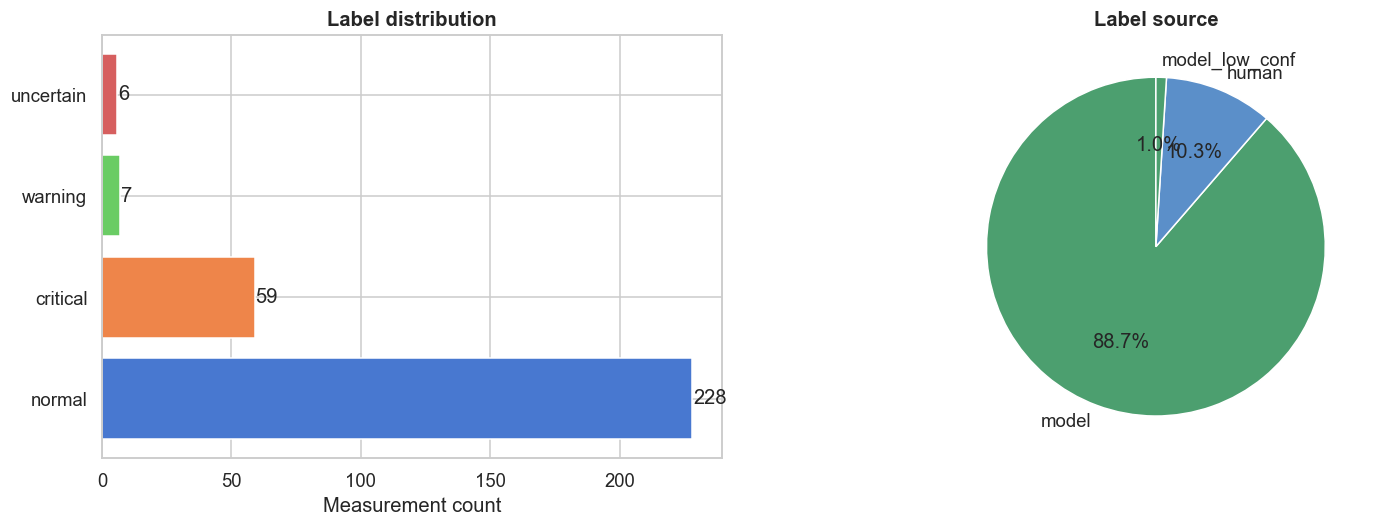

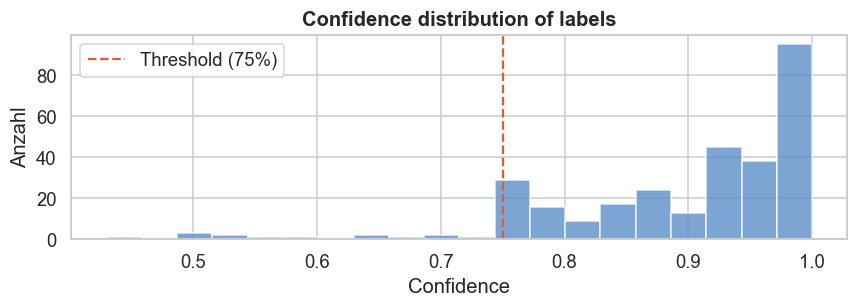

In [24]:
df_labeled = pd.read_sql(
    "SELECT * FROM measurements WHERE label IS NOT NULL", conn)

if len(df_labeled) == 0:
    print('No labeled data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Distribution
    ax = axes[0]
    vc = df_labeled['label'].value_counts()
    bars = ax.barh(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_title('Label distribution', fontweight='bold')
    ax.set_xlabel('Measurement count')
    for bar, v in zip(bars, vc.values):
        ax.text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center')

    # 2) Label source
    ax = axes[1]
    sc = df_labeled['label_source'].value_counts()
    ax.pie(sc.values, labels=sc.index, autopct='%1.1f%%',
           colors=['#4C9F6F','#5B8FC9'], startangle=90)
    ax.set_title('Label source', fontweight='bold')

    # # 3) PCA-Plot
    # ax = axes[2]
    # X_lbl = df_labeled[FEATURES].values
    # y_lbl = df_labeled['label'].values
    # X_sc  = StandardScaler().fit_transform(X_lbl)
    # pca   = PCA(n_components=2)
    # X_2d  = pca.fit_transform(X_sc)
    # classes = sorted(set(y_lbl))
    # palette = sns.color_palette('muted', len(classes))
    # for cls, col in zip(classes, palette):
    #     mask = y_lbl == cls
    #     ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls, alpha=0.7, s=40, color=col)
    # ax.set_title(f'PCA (erkl. Varianz: {pca.explained_variance_ratio_.sum():.0%})', fontweight='bold')
    # ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    # ax.legend(fontsize=8)

    # plt.suptitle('Labeling-Ergebnisse', fontsize=14, fontweight='bold', y=1.01)
    # plt.tight_layout()
    # plt.show()

    # Confidence distribution
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(df_labeled['confidence'].dropna(), bins=20, color='#5B8FC9',
            alpha=0.8, edgecolor='white')
    ax.axvline(UNCERTAINTY_THRESHOLD, color='#D95F3B', ls='--', lw=1.5,
               label=f'Threshold ({UNCERTAINTY_THRESHOLD:.0%})')
    ax.set_title('Confidence distribution of labels', fontweight='bold')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Anzahl')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Classification report
if learner.trained and len(df_labeled) > 0:
    X_lbl = df_labeled[FEATURES].values
    y_lbl = df_labeled['label'].values
    y_pred = learner.le.inverse_transform(learner.model.predict(X_lbl))
    print('Classification report of the labeled data')
    print(classification_report(y_lbl, y_pred))

    cm = confusion_matrix(y_lbl, y_pred, labels=learner.le.classes_)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=learner.le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

## Export


In [26]:
export_path = f'data/out/labeled_measurements_{DB_NAME}.csv'
df_export = pd.read_sql('SELECT * FROM measurements WHERE label IS NOT NULL', conn)
df_export.to_csv(export_path, index=False)
print(f'{len(df_export)} labeled measurements exported → {export_path}')
df_export.head()

300 labeled measurements exported → data/out/labeled_measurements_data_mock.db.csv


,id,urine_volume,max_flow,avg_flow,micturition_time,flow_time,rise_time,label,label_source,confidence,reviewed_at
0,1,190.0,25.9,15.2,30.0,29.9,6.5,normal,model,0.96,2026-04-13T15:10:03.448586
1,2,218.9,27.3,16.1,21.2,19.1,3.2,normal,model,0.92,2026-04-13T15:10:03.449587
2,3,276.7,14.9,8.6,19.3,17.5,2.2,normal,model,0.81,2026-04-13T15:11:40.104345
3,4,243.0,15.5,10.6,23.3,22.6,4.0,normal,model,0.95,2026-04-13T15:10:24.039756
4,5,689.7,20.4,11.7,29.5,26.7,3.0,normal,model,0.98,2026-04-13T15:10:24.039756
